In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, ReLU, Dense, Flatten, Dropout
from tensorflow.keras.datasets import cifar10
from PIL import Image

I0000 00:00:1788103048.276696    1039 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788103048.338085    1039 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788103068.637045    1039 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788103084.247162    1039 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train=X_train[:10000]
X_test=X_test[:2000]
y_train=y_train[:10000]
y_test=y_test[:2000]

In [3]:
X_train = X_train.reshape(-1,32,32,3)/255
X_test = X_test.reshape(-1,32,32,3)/255


In [4]:
X_train.shape

(10000, 32, 32, 3)

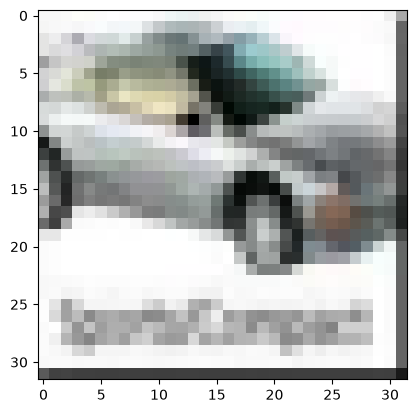

In [5]:
plt.imshow(X_train[79])

In [6]:
cnn = Sequential([
    Conv2D(32,(3,3), input_shape=(32,32,3),activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3)),
    MaxPooling2D((2,2)),
    ReLU(),
    Conv2D(128,(3,3)),
    MaxPooling2D((2,2)),
    ReLU(),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(10, activation="softmax")
])
cnn.compile(optimizer="adam",loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn.fit(X_train, y_train, epochs =9, verbose=2, validation_data=(X_test, y_test), batch_size=32)

/workspaces/229404462/.venv-1/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1788103117.223959    1039 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/9
313/313 - 9s - 28ms/step - accuracy: 0.1440 - loss: 2.1864 - val_accuracy: 0.2410 - val_loss: 1.9872
Epoch 2/9
313/313 - 9s - 29ms/step - accuracy: 0.2359 - loss: 1.9172 - val_accuracy: 0.2965 - val_loss: 1.8217
Epoch 3/9
313/313 - 10s - 32ms/step - accuracy: 0.2862 - loss: 1.7987 - val_accuracy: 0.3460 - val_loss: 1.7349
Epoch 4/9
313/313 - 6s - 18ms/step - accuracy: 0.3610 - loss: 1.6863 - val_accuracy: 0.3835 - val_loss: 1.6169
Epoch 5/9
313/313 - 10s - 33ms/step - accuracy: 0.4080 - loss: 1.5585 - val_accuracy: 0.4280 - val_loss: 1.5475
Epoch 6/9
313/313 - 5s - 17ms/step - accuracy: 0.4583 - loss: 1.4572 - val_accuracy: 0.4365 - val_loss: 1.5160
Epoch 7/9
313/313 - 10s - 34ms/step - accuracy: 0.4988 - loss: 1.3552 - val_accuracy: 0.4765 - val_loss: 1.4361
Epoch 8/9
313/313 - 10s - 32ms/step - accuracy: 0.5343 - loss: 1.2792 - val_accuracy: 0.5255 - val_loss: 1.3220
Epoch 9/9
313/313 - 6s - 18ms/step - accuracy: 0.5683 - loss: 1.1876 - val_accuracy: 0.5215 - val_loss: 1.31

In [7]:
objects ={
    0:"airplane",
    1:"automobile",
    2:"bird",
    3:"cat",
    4:"deer",
    5:"dog",
    6:"frog",
    7:"horse",
    8:"ship",
    9:"truck"
}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Pred Number:  7


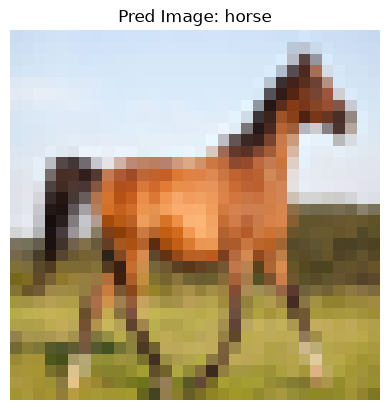

In [8]:
def pred(file):
    img = Image.open(file).convert("RGB")
    img = img.resize((32,32))
    img_array= np.array(img)/255.0
    img_array= np.expand_dims(img_array, axis=0)
    pred = cnn.predict(img_array)
    pred_max = np.argmax(pred)
    objectss = objects[pred_max]
    print("Pred Number: ", pred_max)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Pred Image: {objectss}")
    plt.show()
inputt = input("Enter the file path of the image you want to make a prediction for: ")
pred(inputt)

In [9]:
test_loss, test_acc = cnn.evaluate(X_test, y_test, verbose=1)
print("Model Doğruluğu: ", test_acc)

 9/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4896 - loss: 1.3585 

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5215 - loss: 1.3133
Model Doğruluğu:  0.5214999914169312
